In [2]:
!git clone -b rogelio_resnet50_modeling  https://github.com/seanmcgowanx/coral-reef-classification.git

fatal: destination path 'coral-reef-classification' already exists and is not an empty directory.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install -q -r /content/coral-reef-classification/requirements.txt

# ResNet-50

In [5]:
import sys
import os

def in_colab():
    return "COLAB_GPU" in os.environ or "google.colab" in sys.modules

if in_colab():
    # Running in Google Colab
    repo_path = "/content/coral-reef-classification"
    data_path = "/content/coral-reef-classification/data/processed"

    # Set working directory to the repo root
    os.chdir(repo_path)

else:
    # Running locally in VS Code
    repo_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
    data_path = os.path.abspath(os.path.join(repo_path, "data", "processed"))

    # Add repo root to Python path
    if repo_path not in sys.path:
        sys.path.append(repo_path)

    # Set working directory to the repo root
    os.chdir(repo_path)

print("Using repo path:", repo_path)
print("Using data path:", data_path)
print("CWD:", os.getcwd())

Using repo path: /content/coral-reef-classification
Using data path: /content/coral-reef-classification/data/processed
CWD: /content/coral-reef-classification


In [14]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.models import resnet50, ResNet50_Weights
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

# Import custom functions
from src.s3_loader import get_image_s3
from src.save_fig import save_fig

### Data Augmentations

In [7]:
# ImageNet statistics for normalization
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Define data augmentations and transformations
train_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Define test/validation transformations
test_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

### Build the CoralReefDataset Class

In [8]:
class CoralReefDataset(Dataset):
    def __init__(self, data, transform=None):
        # Accept either a DataFrame or a CSV path
        if isinstance(data, str):
            self.df = pd.read_csv(data)
        else:
            self.df = data.reset_index(drop=True)

        # Drop region_name if it exists
        if "region_name" in self.df.columns:
            self.df = self.df.drop(columns=["region_name"])

        self.transform = transform
        self.image_ids = self.df["image_id"].tolist()
        self.label_cols = self.df.columns[1:].tolist()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]

        # Load image from S3
        image = get_image_s3(image_id)

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        # Get labels as float32 tensor
        labels = torch.tensor(
            self.df.loc[idx, self.label_cols].values.astype("float32")
        )

        return image, labels

### Create Train, Validation, Test Datasets

In [9]:
train_csv = os.path.join(data_path, "final_labels_train.csv")
test_csv = os.path.join(data_path, "final_labels_test.csv")

# Load CSVs
df_train_full = pd.read_csv(train_csv)
df_test = pd.read_csv(test_csv)

# Extract label matrix for train / test splits
class_names = df_train_full.columns[2:]
y = df_train_full[class_names].values

msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.05,
    random_state=42
)

# Assign train / test splits
for train_idx, val_idx in msss.split(df_train_full, y):
    train_df = df_train_full.iloc[train_idx].reset_index(drop=True)
    val_df = df_train_full.iloc[val_idx].reset_index(drop=True)

# Build datasets
train_dataset = CoralReefDataset(train_df, transform=train_transform)
val_dataset = CoralReefDataset(val_df, transform=test_transform)
test_dataset = CoralReefDataset(df_test, transform=test_transform)

### Create DataLoaders

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

### Build and configure the ResNet-50 model

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load ImageNet-pretrained weights
weights = ResNet50_Weights.IMAGENET1K_V1
model = resnet50(weights=weights)

# Replace the final fully connected layer
num_features = model.fc.in_features
num_classes = len(class_names)  # should be 16
model.fc = nn.Linear(num_features, num_classes)

# Move model to device
model = model.to(device)

# Loss function for multi-label classification
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

# Cosine Annealing LR scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10    # cycles every 10 epochs
)

print("\nModel successfully built:")
print(model)
print(f"\nNumber of trainable parameters: "
      f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Using device: cuda

Model successfully built:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): C

### Stage 1 Training Loop



In [17]:
def compute_metrics(logits, targets, threshold=0.5):
    """
    Computes macro precision, recall, F1 for multi-label outputs.
    """
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()

    tp = (preds * targets).sum(dim=0)
    fp = (preds * (1 - targets)).sum(dim=0)
    fn = ((1 - preds) * targets).sum(dim=0)

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return (
        precision.mean().item(),
        recall.mean().item(),
        f1.mean().item()
    )


def validate(model, loader, criterion, device, threshold=0.5):
    """Run one validation epoch."""
    model.eval()

    total_loss = 0
    total_p, total_r, total_f1 = 0, 0, 0
    n_batches = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            p, r, f1 = compute_metrics(logits, labels, threshold)

            total_loss += loss.item()
            total_p += p
            total_r += r
            total_f1 += f1
            n_batches += 1

    return (
        total_loss / n_batches,
        total_p / n_batches,
        total_r / n_batches,
        total_f1 / n_batches
    )


def train_stage_1(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    num_epochs=10,
    threshold=0.5,
    ckpt_path="resnet50_stage1_best.pth"
):
    history = {
      "train_loss": [],
      "val_loss": []
    }

    best_val_f1 = 0.0

    print("\n===== Starting Stage 1 Training =====\n")

    for epoch in range(1, num_epochs + 1):
        model.train()

        running_loss = 0.0
        running_p = 0.0
        running_r = 0.0
        running_f1 = 0.0
        n_batches = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            p, r, f1 = compute_metrics(logits.detach(), labels, threshold)

            running_loss += loss.item()
            running_p += p
            running_r += r
            running_f1 += f1
            n_batches += 1

        train_loss = running_loss / n_batches
        train_p = running_p / n_batches
        train_r = running_r / n_batches
        train_f1 = running_f1 / n_batches

        # Validation epoch
        val_loss, val_p, val_r, val_f1 = validate(
            model, val_loader, criterion, device, threshold
        )

        # LR step
        if scheduler is not None:
            scheduler.step()

        print(
            f"Epoch [{epoch}/{num_epochs}]\n"
            f"  Train Loss: {train_loss:.4f} | P: {train_p:.4f} | R: {train_r:.4f} | F1: {train_f1:.4f}\n"
            f"  Val   Loss: {val_loss:.4f} | P: {val_p:.4f} | R: {val_r:.4f} | F1: {val_f1:.4f}\n"
        )

        # Save best Stage 2 model
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "class_names": class_names.tolist(),
                },
                ckpt_path
            )
            print(f"New best Stage 1 model saved. Val F1 = {best_val_f1:.4f}\n")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

    return history

### Run Stage 1 Training

In [18]:
history_stage1 = train_stage_1(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=10,
    ckpt_path="resnet50_stage1_best.pth"
)


===== Starting Stage 1 Training =====

Epoch [1/10]
  Train Loss: 0.3420 | P: 0.5567 | R: 0.4834 | F1: 0.4932
  Val   Loss: 0.3788 | P: 0.5095 | R: 0.4441 | F1: 0.4537

New best Stage 1 model saved. Val F1 = 0.4537

Epoch [2/10]
  Train Loss: 0.3237 | P: 0.5902 | R: 0.5129 | F1: 0.5261
  Val   Loss: 0.3868 | P: 0.4943 | R: 0.4400 | F1: 0.4433

Epoch [3/10]
  Train Loss: 0.3094 | P: 0.6050 | R: 0.5324 | F1: 0.5414
  Val   Loss: 0.3725 | P: 0.5246 | R: 0.4612 | F1: 0.4661

New best Stage 1 model saved. Val F1 = 0.4661

Epoch [4/10]
  Train Loss: 0.2990 | P: 0.6240 | R: 0.5542 | F1: 0.5628
  Val   Loss: 0.3880 | P: 0.5045 | R: 0.4435 | F1: 0.4537

Epoch [5/10]
  Train Loss: 0.2817 | P: 0.6475 | R: 0.5733 | F1: 0.5834
  Val   Loss: 0.3691 | P: 0.5217 | R: 0.4679 | F1: 0.4751

New best Stage 1 model saved. Val F1 = 0.4751

Epoch [6/10]
  Train Loss: 0.2649 | P: 0.6713 | R: 0.6031 | F1: 0.6126
  Val   Loss: 0.3679 | P: 0.5469 | R: 0.5136 | F1: 0.5125

New best Stage 1 model saved. Val F1 = 

In [19]:
save_path = "/content/drive/MyDrive/resnet50_model/stage_training/"
os.makedirs(save_path, exist_ok=True)

# Save model weights
torch.save(model.state_dict(), save_path + "resnet50_stage1_best.pth")

print("Saved model to:", save_path)

Saved model to: /content/drive/MyDrive/resnet50_model/stage_training/


### Plot Stage 1 Learning Curves

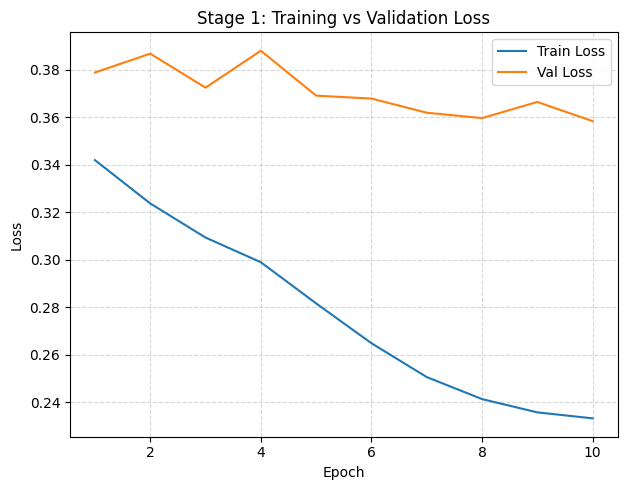

In [20]:
epochs = range(1, len(history_stage1["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs, history_stage1["train_loss"], label="Train Loss")
plt.plot(epochs, history_stage1["val_loss"], label="Val Loss")
plt.title("Stage 1: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### Stage 2 Training

In [21]:
def unfreeze_stage2(model, freeze_until="layer2"):
    """
    Unfreezes layers deeper than `freeze_until`.
    Valid freeze_until values:
    - 'conv1'
    - 'layer1'
    - 'layer2'
    - 'layer3'
    - 'layer4'
    """

    freeze_map = {
        "conv1": [],
        "layer1": ["layer1", "layer2", "layer3", "layer4"],
        "layer2": ["layer2", "layer3", "layer4"],
        "layer3": ["layer3", "layer4"],
        "layer4": ["layer4"],
    }

    to_unfreeze = freeze_map.get(freeze_until, ["layer3", "layer4"])

    # Freeze everything by default
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze desired deeper layers
    for name, module in model.named_children():
        if name in to_unfreeze:
            for param in module.parameters():
                param.requires_grad = True

    # Ensure classifier is unfrozen
    for param in model.fc.parameters():
        param.requires_grad = True

    print(f"\nStage 2 unfreezing complete. Layers unfrozen: {to_unfreeze}")

In [22]:
# Lower LR for fine-tuning
optimizer_stage2 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,             # lower LR for stable fine-tuning
    weight_decay=1e-6
)

scheduler_stage2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_stage2,
    T_max=10
)

In [23]:
# Stage 2 Training Loop

def train_stage_2(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    num_epochs=10,
    threshold=0.5,
    ckpt_path="resnet50_stage2_best.pth"
):
    history = {
        "train_loss": [],
        "val_loss": []
    }

    best_val_f1 = 0.0

    print("\n===== Starting Stage 2 Fine-Tuning =====\n")

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_loss = 0.0
        total_p = 0.0
        total_r = 0.0
        total_f1 = 0.0
        n_batches = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            p, r, f1 = compute_metrics(logits.detach(), labels, threshold)

            total_loss += loss.item()
            total_p += p
            total_r += r
            total_f1 += f1
            n_batches += 1

        train_loss = total_loss / n_batches
        train_p = total_p / n_batches
        train_r = total_r / n_batches
        train_f1 = total_f1 / n_batches

        # Validation
        val_loss, val_p, val_r, val_f1 = validate(
            model, val_loader, criterion, device, threshold
        )

        # LR scheduler update
        scheduler.step()

        print(
            f"Epoch [{epoch}/{num_epochs}]\n"
            f"  Train Loss: {train_loss:.4f} | P: {train_p:.4f} | R: {train_r:.4f} | F1: {train_f1:.4f}\n"
            f"  Val   Loss: {val_loss:.4f} | P: {val_p:.4f} | R: {val_r:.4f} | F1: {val_f1:.4f}\n"
        )

        # Save best Stage 2 model
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "class_names": class_names.tolist(),
                },
                ckpt_path
            )
            print(f"New best Stage 2 model saved. Val F1 = {best_val_f1:.4f}\n")

        # Log history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

    return history

### Unfreeze remaining layers and Run Stage 2 Traninig

In [ ]:
# Load best Stage 1 checkpoint
checkpoint = torch.load("resnet50_stage1_best.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

# Unfreeze deeper layers
unfreeze_stage2(model, freeze_until="layer2")

# Start Stage 2 fine-tuning
history_stage2 = train_stage_2(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_stage2,
    scheduler=scheduler_stage2,
    device=device,
    num_epochs=10
)


Stage 2 unfreezing complete. Layers unfrozen: ['layer2', 'layer3', 'layer4']

===== Starting Stage 2 Fine-Tuning =====

Epoch [1/10]
  Train Loss: 0.2368 | P: 0.6966 | R: 0.6402 | F1: 0.6464
  Val   Loss: 0.3604 | P: 0.5580 | R: 0.5055 | F1: 0.5116

New best Stage 2 model saved. Val F1 = 0.5116

Epoch [2/10]
  Train Loss: 0.2306 | P: 0.7116 | R: 0.6413 | F1: 0.6540
  Val   Loss: 0.3726 | P: 0.5544 | R: 0.5020 | F1: 0.5053

Epoch [3/10]
  Train Loss: 0.2295 | P: 0.7085 | R: 0.6448 | F1: 0.6545
  Val   Loss: 0.3651 | P: 0.5612 | R: 0.5099 | F1: 0.5149

New best Stage 2 model saved. Val F1 = 0.5149



In [ ]:
save_path = "/content/drive/MyDrive/resnet50_model/stage_training/"
os.makedirs(save_path, exist_ok=True)

# Save model weights
torch.save(model.state_dict(), save_path + "resnet50_stage2_best.pth")

print("Saved model to:", save_path)

### Plot Stage 2 Learning Curve

In [ ]:
epochs = range(1, len(history_stage2["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs, history_stage2["train_loss"], label="Train Loss")
plt.plot(epochs, history_stage2["val_loss"], label="Val Loss")
plt.title("Stage 2: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()